# Домашнее задание: улучшение качества обучения нейросети и Transfer Learning

В работе используется датасет персонажей мультфильма The Simpsons и подход из занятия: `ImageFolder`, train/validation split, `DataLoader`, `CrossEntropyLoss`, `SGD`, функция `train(...)`, история метрик и графики.

Эксперименты:

1. ResNet18 с нуля как базовый эксперимент.
2. ResNet18 с `StepLR`.
3. ResNet18 с `ReduceLROnPlateau`.
4. ResNet18 с чрезмерно сильными train-аугментациями.
5. EfficientNet-B0 как Feature Extractor.
6. EfficientNet-B0 как Fine Tuning.

Результаты обучения не прописаны вручную: таблицы и выводы формируются после фактического запуска ячеек.

## 1. Импорты и настройки

Задаем основные параметры. Для полноценного эксперимента используется `NUM_EPOCHS = 10`. Для быстрой отладки можно временно поставить `NUM_EPOCHS = 2`.

In [1]:
import gc
import random
import subprocess
import sys
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from IPython.display import Markdown, display
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0, resnet18

try:
    from sklearn.model_selection import train_test_split
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'scikit-learn'])
    from sklearn.model_selection import train_test_split

SEED = 42
input_size = 224
batch_size = 64
NUM_EPOCHS = 10
LEARNING_RATE = 0.01
MOMENTUM = 0.9
VAL_SIZE = 0.2
NUM_WORKERS = 2

# Если датасет уже загружен локально, можно указать путь явно.
# Ожидаемая структура: DATA_DIR / class_name / image.jpg
DATA_DIR = Path('simpsons_dataset')

# Нормализация ImageNet нужна для pretrained EfficientNet-B0.
# Ее также используем для ResNet18, чтобы все эксперименты работали с одинаковой предобработкой.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

## 2. Device и random seed

Фиксируем случайные состояния и выбираем GPU, если он доступен.

In [2]:
def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_random_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


## 3. Загрузка датасета Simpsons

Используется `torchvision.datasets.ImageFolder`. Если папка с датасетом уже есть рядом с notebook, код возьмет ее. Если датасет не найден, в Google Colab будет выполнена попытка скачать публичный Kaggle dataset `alexattia/the-simpsons-characters-dataset` через `kagglehub`.

После подготовки должна получиться структура вида:

```text
simpsons_dataset/
    abraham_grampa_simpson/
        pic_0000.jpg
    bart_simpson/
        pic_0000.jpg
    ...
```

In [3]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


def count_direct_images(path):
    path = Path(path)
    return sum(1 for file in path.glob('*') if file.suffix.lower() in IMAGE_EXTENSIONS)


def count_nested_images(path):
    path = Path(path)
    return sum(1 for file in path.rglob('*') if file.suffix.lower() in IMAGE_EXTENSIONS)


def looks_like_imagefolder(path):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False

    class_dirs = [child for child in path.iterdir() if child.is_dir()]
    if len(class_dirs) < 2:
        return False

    dirs_with_images = sum(1 for class_dir in class_dirs if count_direct_images(class_dir) > 0)

    return dirs_with_images >= 2


def imagefolder_score(path):
    path = Path(path)
    class_dirs = [child for child in path.iterdir() if child.is_dir()]
    direct_class_dirs = [child for child in class_dirs if count_direct_images(child) > 0]

    if not direct_class_dirs:
        return (0, 0, 0)

    direct_images = sum(count_direct_images(child) for child in direct_class_dirs)

    # Если внутри одного из class_dirs есть еще целый ImageFolder, это обычно служебная
    # вложенная папка Kaggle, а не настоящий класс. Штрафуем такие корни.
    nested_imagefolders = sum(1 for child in class_dirs if find_imagefolder_root(child, include_self=True) is not None)

    return (direct_images, len(direct_class_dirs), -nested_imagefolders)


def find_imagefolder_root(root, include_self=True):
    root = Path(root)
    if not root.exists():
        return None

    candidates = []
    if include_self and looks_like_imagefolder(root):
        candidates.append(root)

    for path in root.rglob('*'):
        if looks_like_imagefolder(path):
            candidates.append(path)

    if not candidates:
        return None

    # Выбираем самый правдоподобный ImageFolder: максимум прямых изображений
    # в папках классов и без вложенных служебных ImageFolder внутри класса.
    return max(candidates, key=imagefolder_score)


def validate_simpsons_imagefolder(dataset):
    lower_classes = {class_name.lower() for class_name in dataset.classes}
    suspicious_classes = {'simpsons_dataset', 'kaggle_simpson_testset', 'characters_illustration'}

    if lower_classes & suspicious_classes:
        raise ValueError(
            'Выбран неправильный корень датасета: служебная папка попала как класс. '
            f'Текущий data_dir: {data_dir}. Классы: {dataset.classes[:10]}'
        )

    if not 35 <= len(dataset.classes) <= 45:
        raise ValueError(
            f'Подозрительное количество классов: {len(dataset.classes)}. '
            'Для Simpsons dataset обычно ожидается около 42 классов.'
        )

    if not 15000 <= len(dataset) <= 25000:
        print(
            f'Предупреждение: найдено {len(dataset)} изображений. '
            'Это отличается от типичного размера Simpsons dataset, проверьте data_dir.'
        )

    return dataset


def download_simpsons_dataset_with_kagglehub():
    try:
        import kagglehub
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])
        import kagglehub

    downloaded_path = Path(kagglehub.dataset_download('alexattia/the-simpsons-characters-dataset'))
    dataset_root = find_imagefolder_root(downloaded_path)

    if dataset_root is None:
        raise FileNotFoundError(
            'Датасет был скачан, но папка формата ImageFolder не найдена. '
            'Проверьте структуру скачанных файлов.'
        )

    return dataset_root


def prepare_data_dir():
    candidates = [
        DATA_DIR,
        Path('data') / 'simpsons_dataset',
        Path('/content') / 'simpsons_dataset',
        Path('/content') / 'the-simpsons-characters-dataset' / 'simpsons_dataset',
        Path('/content') / 'drive' / 'MyDrive' / 'simpsons_dataset',
    ]

    for candidate in candidates:
        dataset_root = find_imagefolder_root(candidate)
        if dataset_root is not None:
            return dataset_root

    print('Локальная папка Simpsons dataset не найдена. Пробуем скачать датасет через kagglehub...')
    return download_simpsons_dataset_with_kagglehub()


data_dir = prepare_data_dir()
print(f'Папка датасета: {data_dir}')

base_dataset = torchvision.datasets.ImageFolder(data_dir)
validate_simpsons_imagefolder(base_dataset)
print(f'Всего изображений: {len(base_dataset)}')
print(f'Количество классов: {len(base_dataset.classes)}')
print(f'Первые 10 классов: {base_dataset.classes[:10]}')

Локальная папка Simpsons dataset не найдена. Пробуем скачать датасет через kagglehub...
Папка датасета: /kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/simpsons_dataset/simpsons_dataset
Всего изображений: 20933
Количество классов: 42
Первые 10 классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'cletus_spuckler', 'comic_book_guy']


## 4. Train / validation split

Делаем один общий train/validation split и используем его во всех экспериментах. Разделение выполняется с `random_state=SEED` и `stratify=data_image_labels`, чтобы сохранить распределение классов.

In [4]:
def normalize_path(path):
    return str(Path(path).resolve())


data_image_paths = [normalize_path(path) for path, _ in base_dataset.samples]
data_image_labels = [label for _, label in base_dataset.samples]

label_counts = Counter(data_image_labels)
valid_labels = {label for label, count in label_counts.items() if count >= 2}

if len(valid_labels) < len(label_counts):
    skipped_classes = [base_dataset.classes[label] for label in sorted(set(label_counts) - valid_labels)]
    print('Классы с менее чем двумя изображениями не участвуют в split:', skipped_classes)

filtered_paths = []
filtered_labels = []
for path, label in zip(data_image_paths, data_image_labels):
    if label in valid_labels:
        filtered_paths.append(path)
        filtered_labels.append(label)

train_files_path, val_files_path, train_labels, val_labels = train_test_split(
    filtered_paths,
    filtered_labels,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=filtered_labels,
)

train_files_path = set(train_files_path)
val_files_path = set(val_files_path)

print(f'Train изображений: {len(train_files_path)}')
print(f'Validation изображений: {len(val_files_path)}')
print(f'Пересечение train и validation: {len(train_files_path & val_files_path)}')

Train изображений: 16746
Validation изображений: 4187
Пересечение train и validation: 0


## 5. Базовые transforms

Базовые аугментации сохраняют стиль кода с занятия: `Resize`, `CenterCrop`, `ColorJitter`, `RandomAffine`, `ToTensor`. Для совместимости с pretrained EfficientNet-B0 добавлена нормализация ImageNet.

Validation transform остается детерминированным: без случайных аугментаций.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomAffine(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def is_train_file(path):
    return normalize_path(path) in train_files_path


def is_val_file(path):
    return normalize_path(path) in val_files_path


def make_datasets(current_train_transform):
    train_dataset = torchvision.datasets.ImageFolder(
        data_dir,
        transform=current_train_transform,
        is_valid_file=is_train_file,
    )

    val_dataset = torchvision.datasets.ImageFolder(
        data_dir,
        transform=val_transform,
        is_valid_file=is_val_file,
    )

    return train_dataset, val_dataset


train_dataset, val_dataset = make_datasets(train_transform)
num_classes = len(train_dataset.classes)

print(f'Размер train_dataset: {len(train_dataset)}')
print(f'Размер val_dataset: {len(val_dataset)}')
print(f'Количество классов для классификатора: {num_classes}')

Размер train_dataset: 16746
Размер val_dataset: 4187
Количество классов для классификатора: 42


## 6. DataLoader

Создаем генераторы batch-ей. Для train включено перемешивание, для validation оно не нужно.

In [6]:
def make_dataloaders(current_train_dataset, current_val_dataset, current_batch_size=batch_size):
    train_generator = torch.Generator().manual_seed(SEED)
    pin_memory = device == 'cuda'

    train_batch_gen = DataLoader(
        current_train_dataset,
        batch_size=current_batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        generator=train_generator,
    )

    val_batch_gen = DataLoader(
        current_val_dataset,
        batch_size=current_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    return train_batch_gen, val_batch_gen


train_batch_gen, val_batch_gen = make_dataloaders(train_dataset, val_dataset)
images, labels = next(iter(train_batch_gen))

print(f'Форма batch изображений: {tuple(images.shape)}')
print(f'Форма batch меток: {tuple(labels.shape)}')
print(f'Пример labels: {labels[:10].tolist()}')

Форма batch изображений: (64, 3, 224, 224)
Форма batch меток: (64,)
Пример labels: [20, 24, 6, 28, 36, 6, 20, 27, 6, 3]


## 7. Вспомогательные функции

Функция `train(...)` сохраняет стиль занятия, но дополнительно поддерживает LR Scheduler. Для `ReduceLROnPlateau` в `scheduler.step(...)` передается validation loss, для остальных scheduler используется обычный `scheduler.step()`.

Accuracy считается через общее число верных ответов и объектов, поэтому последний неполный batch не искажает метрику.

In [7]:
def clear_gpu_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_learning_rates(optimizer):
    return [param_group['lr'] for param_group in optimizer.param_groups]


def format_learning_rates(optimizer):
    return ', '.join(f'{lr:.6f}' for lr in get_learning_rates(optimizer))


def train(model, criterion, optimizer, train_batch_gen, val_batch_gen, num_epochs=10, scheduler=None):
    history = {
        'loss': {
            'train': [],
            'val': [],
        },
        'acc': {
            'train': [],
            'val': [],
        },
        'lr': [],
        'all_lrs': [],
        'training_time_sec': 0.0,
    }

    model = model.to(device)
    start_time = time.perf_counter()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')

        model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_batch_gen:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size_current = labels.size(0)
            preds = outputs.argmax(dim=1)
            train_running_loss += loss.item() * batch_size_current
            train_correct += (preds == labels).sum().item()
            train_total += batch_size_current

        train_loss = train_running_loss / train_total
        train_acc = train_correct / train_total

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_batch_gen:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                batch_size_current = labels.size(0)
                preds = outputs.argmax(dim=1)
                val_running_loss += loss.item() * batch_size_current
                val_correct += (preds == labels).sum().item()
                val_total += batch_size_current

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        current_lrs = get_learning_rates(optimizer)

        history['loss']['train'].append(train_loss)
        history['loss']['val'].append(val_loss)
        history['acc']['train'].append(train_acc)
        history['acc']['val'].append(val_acc)
        history['lr'].append(current_lrs[0])
        history['all_lrs'].append(current_lrs)

        print(f'Train Loss: {train_loss:.4f}')
        print(f'Validation Loss: {val_loss:.4f}')
        print(f'Train Accuracy: {train_acc:.2%}')
        print(f'Validation Accuracy: {val_acc:.2%}')
        print(f'Learning rate: {format_learning_rates(optimizer)}')

    history['training_time_sec'] = time.perf_counter() - start_time
    return model, history


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def best_val_accuracy(history):
    return max(history['acc']['val'])


def final_val_accuracy(history):
    return history['acc']['val'][-1]


def best_val_loss(history):
    return min(history['loss']['val'])


def plot_history(history, title):
    epochs = range(1, len(history['loss']['train']) + 1)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['loss']['train'], label='train loss')
    plt.plot(epochs, history['loss']['val'], label='val loss')
    plt.title(f'{title}: loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['acc']['train'], label='train accuracy')
    plt.plot(epochs, history['acc']['val'], label='val accuracy')
    plt.title(f'{title}: accuracy')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lr'], marker='o', label='learning rate')
    plt.title(f'{title}: learning rate')
    plt.xlabel('Эпоха')
    plt.ylabel('LR')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def print_history_summary(title, history):
    print(f'{title}')
    print(f"Best validation accuracy: {best_val_accuracy(history):.2%}")
    print(f"Final validation accuracy: {final_val_accuracy(history):.2%}")
    print(f"Best validation loss: {best_val_loss(history):.4f}")
    print(f"Training time: {history['training_time_sec']:.1f} sec")

## 8. Базовый эксперимент: ResNet18 с нуля

Этот эксперимент нужен как точка отсчета. Модель ResNet18 создается без pretrained весов и обучается с нуля, как в коде занятия.


Epoch 1/10
Train Loss: 2.7229
Validation Loss: 2.1007
Train Accuracy: 24.27%
Validation Accuracy: 41.87%
Learning rate: 0.010000

Epoch 2/10
Train Loss: 1.7598
Validation Loss: 1.4107
Train Accuracy: 51.88%
Validation Accuracy: 61.40%
Learning rate: 0.010000

Epoch 3/10
Train Loss: 1.1385
Validation Loss: 0.9390
Train Accuracy: 69.36%
Validation Accuracy: 74.78%
Learning rate: 0.010000

Epoch 4/10
Train Loss: 0.8088
Validation Loss: 0.9516
Train Accuracy: 77.80%
Validation Accuracy: 74.30%
Learning rate: 0.010000

Epoch 5/10
Train Loss: 0.6092
Validation Loss: 0.7007
Train Accuracy: 83.51%
Validation Accuracy: 81.75%
Learning rate: 0.010000

Epoch 6/10
Train Loss: 0.4819
Validation Loss: 0.6770
Train Accuracy: 86.64%
Validation Accuracy: 82.06%
Learning rate: 0.010000

Epoch 7/10
Train Loss: 0.3865
Validation Loss: 0.8097
Train Accuracy: 89.51%
Validation Accuracy: 79.60%
Learning rate: 0.010000

Epoch 8/10
Train Loss: 0.3000
Validation Loss: 0.7776
Train Accuracy: 91.38%
Validation A

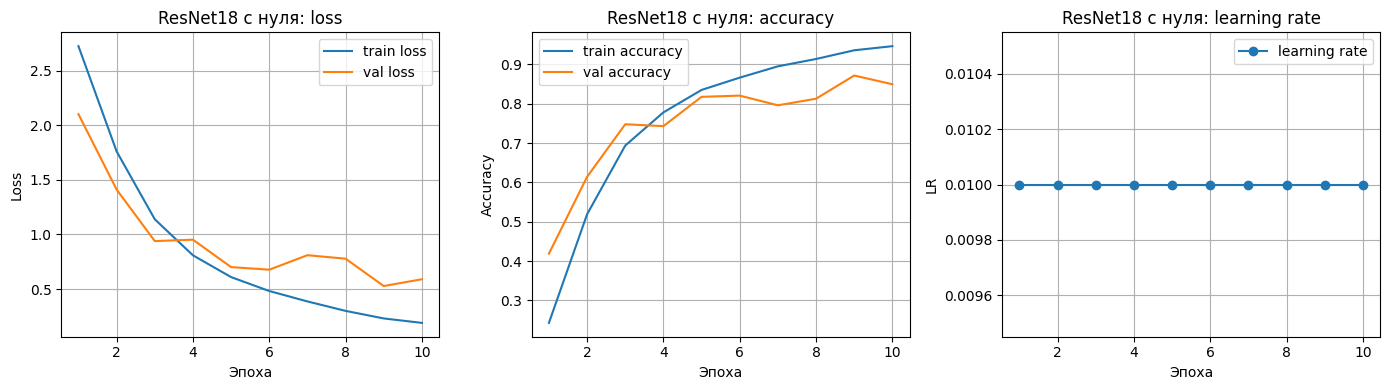

In [8]:
def create_resnet18_scratch(num_classes):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


set_random_seed(SEED)
baseline_model = create_resnet18_scratch(num_classes)
baseline_total_params = count_parameters(baseline_model)
baseline_trainable_params = count_trainable_parameters(baseline_model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(baseline_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

baseline_model, baseline_history = train(
    baseline_model,
    criterion,
    optimizer,
    train_batch_gen,
    val_batch_gen,
    num_epochs=NUM_EPOCHS,
)

print_history_summary('ResNet18 с нуля', baseline_history)
plot_history(baseline_history, 'ResNet18 с нуля')

del baseline_model, optimizer
clear_gpu_memory()

## 9. LR Scheduler - StepLR

`StepLR` уменьшает learning rate через фиксированное число эпох. Здесь проверяем, как ступенчатое уменьшение LR влияет на loss и accuracy при той же архитектуре, split, аугментациях и стартовом learning rate.


Epoch 1/10
Train Loss: 2.7385
Validation Loss: 2.0595
Train Accuracy: 24.31%
Validation Accuracy: 40.84%
Learning rate: 0.010000

Epoch 2/10
Train Loss: 1.7605
Validation Loss: 1.5733
Train Accuracy: 52.21%
Validation Accuracy: 56.96%
Learning rate: 0.010000

Epoch 3/10
Train Loss: 1.1643
Validation Loss: 1.0864
Train Accuracy: 68.30%
Validation Accuracy: 71.77%
Learning rate: 0.005000

Epoch 4/10
Train Loss: 0.7267
Validation Loss: 0.7318
Train Accuracy: 80.38%
Validation Accuracy: 80.03%
Learning rate: 0.005000

Epoch 5/10
Train Loss: 0.5837
Validation Loss: 0.7864
Train Accuracy: 84.36%
Validation Accuracy: 77.53%
Learning rate: 0.005000

Epoch 6/10
Train Loss: 0.4858
Validation Loss: 0.5952
Train Accuracy: 86.99%
Validation Accuracy: 83.81%
Learning rate: 0.002500

Epoch 7/10
Train Loss: 0.3577
Validation Loss: 0.4210
Train Accuracy: 90.91%
Validation Accuracy: 88.49%
Learning rate: 0.002500

Epoch 8/10
Train Loss: 0.3139
Validation Loss: 0.4439
Train Accuracy: 91.84%
Validation A

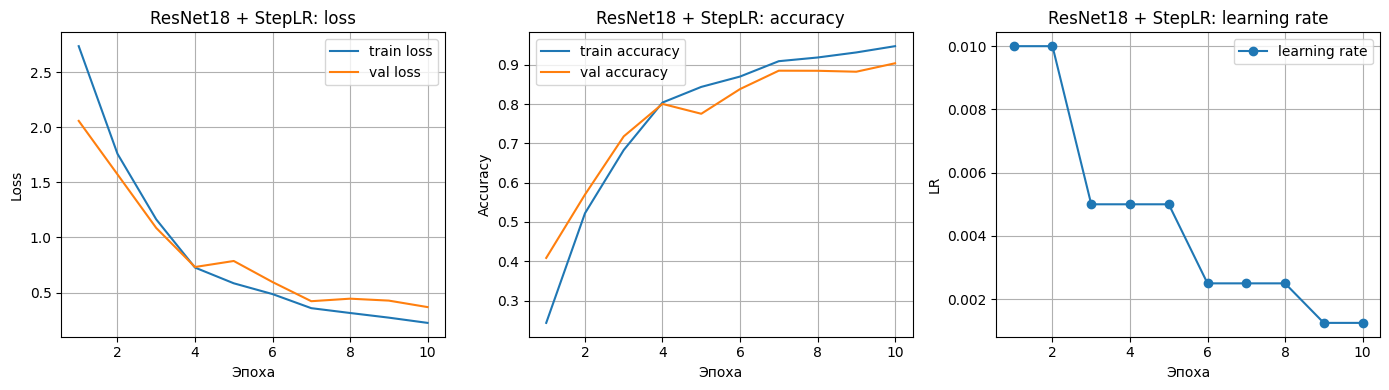

In [9]:
set_random_seed(SEED)
step_lr_model = create_resnet18_scratch(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(step_lr_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5,
)

step_lr_model, step_lr_history = train(
    step_lr_model,
    criterion,
    optimizer,
    train_batch_gen,
    val_batch_gen,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
)

print_history_summary('ResNet18 + StepLR', step_lr_history)
plot_history(step_lr_history, 'ResNet18 + StepLR')

del step_lr_model, optimizer, scheduler
clear_gpu_memory()

## 10. LR Scheduler - ReduceLROnPlateau

`ReduceLROnPlateau` уменьшает learning rate, когда validation loss перестает улучшаться. Для него важно вызывать `scheduler.step(val_loss)`, поэтому validation loss передается явно.


Epoch 1/10
Train Loss: 2.6900
Validation Loss: 1.9169
Train Accuracy: 25.25%
Validation Accuracy: 48.39%
Learning rate: 0.010000

Epoch 2/10
Train Loss: 1.7540
Validation Loss: 1.3748
Train Accuracy: 52.19%
Validation Accuracy: 63.03%
Learning rate: 0.010000

Epoch 3/10
Train Loss: 1.1437
Validation Loss: 1.3268
Train Accuracy: 68.98%
Validation Accuracy: 65.89%
Learning rate: 0.010000

Epoch 4/10
Train Loss: 0.8234
Validation Loss: 1.1028
Train Accuracy: 77.76%
Validation Accuracy: 71.91%
Learning rate: 0.010000

Epoch 5/10
Train Loss: 0.6150
Validation Loss: 0.5919
Train Accuracy: 83.06%
Validation Accuracy: 84.36%
Learning rate: 0.010000

Epoch 6/10
Train Loss: 0.4868
Validation Loss: 1.1919
Train Accuracy: 86.96%
Validation Accuracy: 71.96%
Learning rate: 0.010000

Epoch 7/10
Train Loss: 0.3742
Validation Loss: 0.4940
Train Accuracy: 89.83%
Validation Accuracy: 87.15%
Learning rate: 0.010000

Epoch 8/10
Train Loss: 0.2994
Validation Loss: 0.7099
Train Accuracy: 91.75%
Validation A

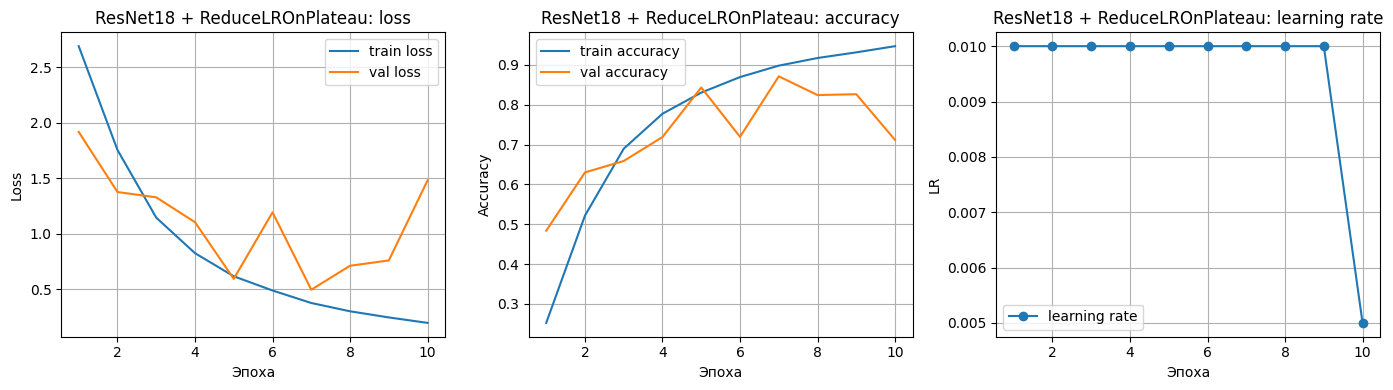

In [10]:
set_random_seed(SEED)
plateau_model = create_resnet18_scratch(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(plateau_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

plateau_model, plateau_history = train(
    plateau_model,
    criterion,
    optimizer,
    train_batch_gen,
    val_batch_gen,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
)

print_history_summary('ResNet18 + ReduceLROnPlateau', plateau_history)
plot_history(plateau_history, 'ResNet18 + ReduceLROnPlateau')

del plateau_model, optimizer, scheduler
clear_gpu_memory()

## 11. Сравнение Scheduler

Таблица строится программно из истории обучения. Результаты не вписываются вручную.

,Experiment,Scheduler,Best val accuracy,Final val accuracy,Best val loss
0,Experiment 1,StepLR,0.903750,0.903750,0.367494
1,Experiment 2,ReduceLROnPlateau,0.871507,0.711727,0.494039


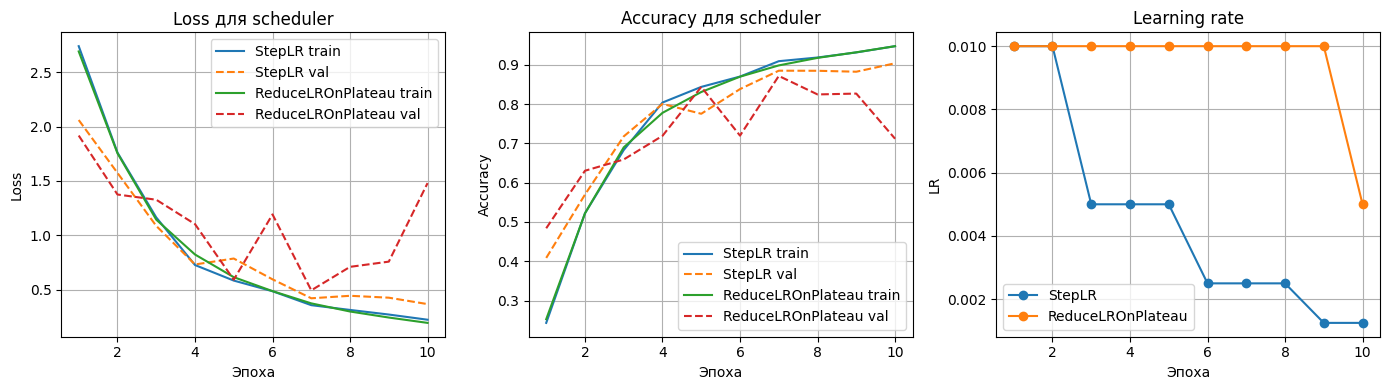

In [11]:
scheduler_histories = {
    'StepLR': step_lr_history,
    'ReduceLROnPlateau': plateau_history,
}

scheduler_comparison_df = pd.DataFrame([
    {
        'Experiment': experiment_name,
        'Scheduler': scheduler_name,
        'Best val accuracy': best_val_accuracy(history),
        'Final val accuracy': final_val_accuracy(history),
        'Best val loss': best_val_loss(history),
    }
    for experiment_name, scheduler_name, history in [
        ('Experiment 1', 'StepLR', step_lr_history),
        ('Experiment 2', 'ReduceLROnPlateau', plateau_history),
    ]
])

display(scheduler_comparison_df)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
for name, history in scheduler_histories.items():
    epochs = range(1, len(history['loss']['train']) + 1)
    plt.plot(epochs, history['loss']['train'], label=f'{name} train')
    plt.plot(epochs, history['loss']['val'], linestyle='--', label=f'{name} val')
plt.title('Loss для scheduler')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
for name, history in scheduler_histories.items():
    epochs = range(1, len(history['acc']['train']) + 1)
    plt.plot(epochs, history['acc']['train'], label=f'{name} train')
    plt.plot(epochs, history['acc']['val'], linestyle='--', label=f'{name} val')
plt.title('Accuracy для scheduler')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
for name, history in scheduler_histories.items():
    epochs = range(1, len(history['lr']) + 1)
    plt.plot(epochs, history['lr'], marker='o', label=name)
plt.title('Learning rate')
plt.xlabel('Эпоха')
plt.ylabel('LR')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Эксперимент с чрезмерными аугментациями

Здесь сравниваем нормальные train-аугментации и намеренно плохие train-аугментации. Validation transform остается тем же самым и не содержит случайных изменений.

Плохие аугментации не удаляют изображение полностью, но слишком сильно меняют геометрию, перспективу, цвет и закрывают часть изображения. Из-за этого train-распределение становится хуже похоже на validation-распределение, а важные признаки персонажей искажаются.

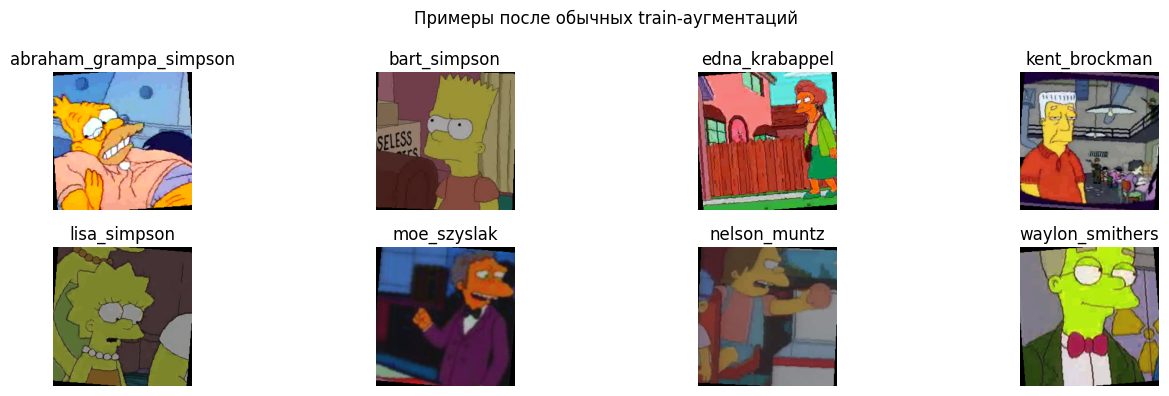

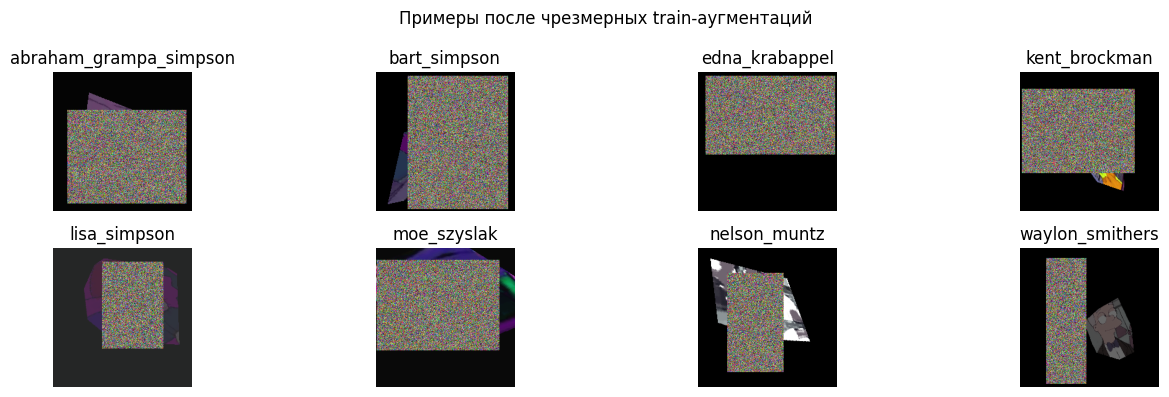

In [12]:
bad_train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.RandomRotation(120),
    transforms.RandomAffine(
        degrees=55,
        translate=(0.35, 0.35),
        scale=(0.45, 1.65),
        shear=35,
    ),
    transforms.RandomPerspective(distortion_scale=0.75, p=0.9),
    transforms.ColorJitter(brightness=1.4, contrast=1.4, saturation=1.4, hue=0.45),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.9, scale=(0.25, 0.70), ratio=(0.3, 3.3), value='random'),
])


def denormalize_image(tensor_image):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = tensor_image.cpu() * std + mean
    return image.clamp(0, 1)


def show_augmented_images(dataset, title, n_images=8):
    indices = np.linspace(0, len(dataset) - 1, n_images, dtype=int)
    plt.figure(figsize=(14, 4))

    for plot_index, dataset_index in enumerate(indices, start=1):
        image, label = dataset[dataset_index]
        image = denormalize_image(image).permute(1, 2, 0).numpy()

        plt.subplot(2, 4, plot_index)
        plt.imshow(image)
        plt.title(dataset.classes[label])
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


bad_train_dataset, bad_val_dataset = make_datasets(bad_train_transform)
bad_train_batch_gen, bad_val_batch_gen = make_dataloaders(bad_train_dataset, bad_val_dataset)

show_augmented_images(train_dataset, 'Примеры после обычных train-аугментаций')
show_augmented_images(bad_train_dataset, 'Примеры после чрезмерных train-аугментаций')


Epoch 1/10
Train Loss: 3.2136
Validation Loss: 3.1301
Train Accuracy: 8.27%
Validation Accuracy: 10.68%
Learning rate: 0.010000

Epoch 2/10
Train Loss: 3.1396
Validation Loss: 3.1243
Train Accuracy: 9.54%
Validation Accuracy: 6.85%
Learning rate: 0.010000

Epoch 3/10
Train Loss: 3.1322
Validation Loss: 3.1168
Train Accuracy: 9.87%
Validation Accuracy: 10.84%
Learning rate: 0.010000

Epoch 4/10
Train Loss: 3.1264
Validation Loss: 3.0981
Train Accuracy: 10.18%
Validation Accuracy: 10.72%
Learning rate: 0.010000

Epoch 5/10
Train Loss: 3.1202
Validation Loss: 3.0984
Train Accuracy: 10.12%
Validation Accuracy: 10.56%
Learning rate: 0.010000

Epoch 6/10
Train Loss: 3.1179
Validation Loss: 3.0975
Train Accuracy: 10.66%
Validation Accuracy: 9.74%
Learning rate: 0.010000

Epoch 7/10
Train Loss: 3.1162
Validation Loss: 3.0863
Train Accuracy: 10.29%
Validation Accuracy: 10.29%
Learning rate: 0.010000

Epoch 8/10
Train Loss: 3.1161
Validation Loss: 3.0911
Train Accuracy: 10.47%
Validation Accura

,Experiment,Best validation accuracy,Final validation accuracy
0,Normal train augmentations,0.871746,0.849534
1,Bad train augmentations,0.119895,0.095295


Падение best validation accuracy: 75.19 процентных пункта
Цель выполнена: падение больше 10 процентных пунктов.


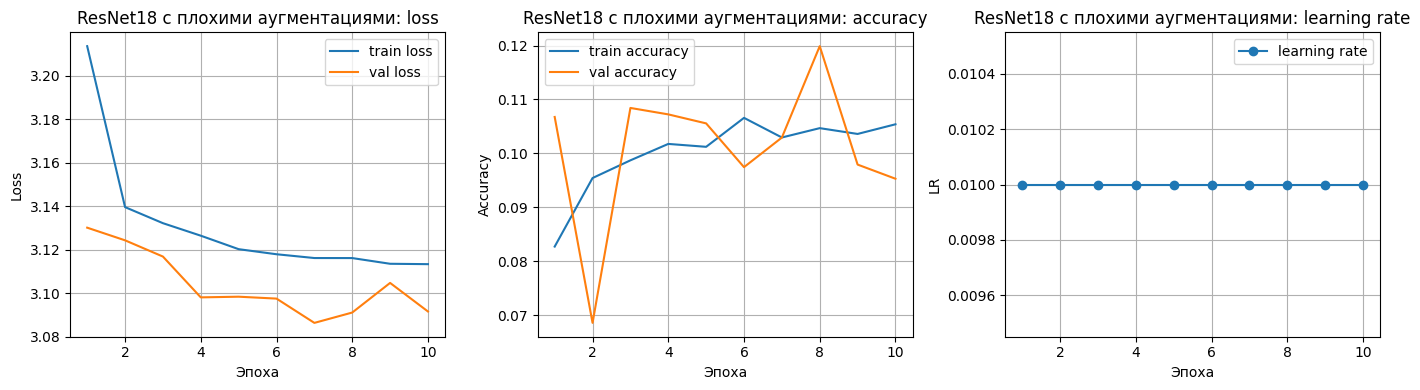

In [13]:
# Нормальный вариант уже был обучен в базовом эксперименте ResNet18 с нуля.
normal_best_val_accuracy = best_val_accuracy(baseline_history)

set_random_seed(SEED)
bad_aug_model = create_resnet18_scratch(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(bad_aug_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

bad_aug_model, bad_aug_history = train(
    bad_aug_model,
    criterion,
    optimizer,
    bad_train_batch_gen,
    bad_val_batch_gen,
    num_epochs=NUM_EPOCHS,
)

bad_aug_best_val_accuracy = best_val_accuracy(bad_aug_history)
accuracy_drop = normal_best_val_accuracy - bad_aug_best_val_accuracy

augmentation_comparison_df = pd.DataFrame([
    {
        'Experiment': 'Normal train augmentations',
        'Best validation accuracy': normal_best_val_accuracy,
        'Final validation accuracy': final_val_accuracy(baseline_history),
    },
    {
        'Experiment': 'Bad train augmentations',
        'Best validation accuracy': bad_aug_best_val_accuracy,
        'Final validation accuracy': final_val_accuracy(bad_aug_history),
    },
])

display(augmentation_comparison_df)
print(f'Падение best validation accuracy: {accuracy_drop * 100:.2f} процентных пункта')

if accuracy_drop > 0.10:
    print('Цель выполнена: падение больше 10 процентных пунктов.')
else:
    print('Падение меньше 10 процентных пунктов. В этом случае нужно усилить bad_train_transform и повторить эксперимент.')

plot_history(bad_aug_history, 'ResNet18 с плохими аугментациями')

del bad_aug_model, optimizer
clear_gpu_memory()

## 13. EfficientNet-B0 - Feature Extractor

Feature Extractor означает, что pretrained backbone используется как готовый извлекатель признаков. Все параметры backbone заморожены, а обучается только новый классификатор под классы Simpsons.

Такой подход часто быстрее и дешевле по вычислениям, потому что обновляется небольшое число параметров.

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]


Всего параметров: 4 061 350
Обучаемых параметров: 53 802
Обучаемые параметры:
  classifier.1.weight
  classifier.1.bias

Epoch 1/10
Train Loss: 2.3468
Validation Loss: 1.6789
Train Accuracy: 43.43%
Validation Accuracy: 61.50%
Learning rate: 0.010000

Epoch 2/10
Train Loss: 1.7035
Validation Loss: 1.4036
Train Accuracy: 57.92%
Validation Accuracy: 66.52%
Learning rate: 0.010000

Epoch 3/10
Train Loss: 1.5369
Validation Loss: 1.2835
Train Accuracy: 60.76%
Validation Accuracy: 68.14%
Learning rate: 0.010000

Epoch 4/10
Train Loss: 1.4354
Validation Loss: 1.1929
Train Accuracy: 62.30%
Validation Accuracy: 70.22%
Learning rate: 0.010000

Epoch 5/10
Train Loss: 1.3651
Validation Loss: 1.1436
Train Accuracy: 64.10%
Validation Accuracy: 70.67%
Learning rate: 0.010000

Epoch 6/10
Train Loss: 1.3015
Validation Loss: 1.0908
Train Accuracy: 65.33%
Validation Accuracy: 72.13%
Learning rate: 0.010000

Epoch 7/10
Train Loss: 1.2795
Validation Loss: 1.0722
Train Accuracy: 65.88%
Validation Accuracy: 7

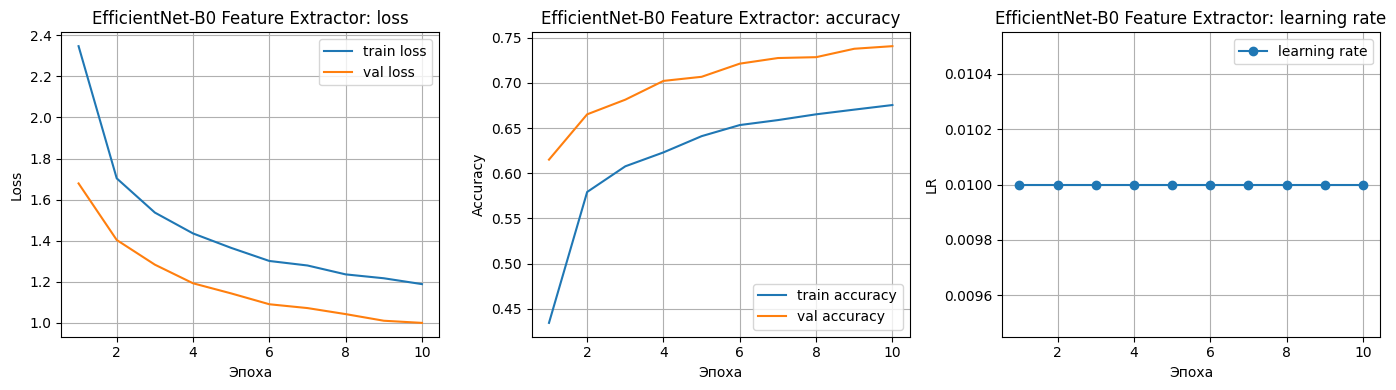

In [14]:
def create_efficientnet_b0_feature_extractor(num_classes):
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model


def show_trainable_parameters(model, max_names=20):
    trainable_names = [name for name, param in model.named_parameters() if param.requires_grad]
    print(f'Всего параметров: {count_parameters(model):,}'.replace(',', ' '))
    print(f'Обучаемых параметров: {count_trainable_parameters(model):,}'.replace(',', ' '))
    print('Обучаемые параметры:')
    for name in trainable_names[:max_names]:
        print(f'  {name}')
    if len(trainable_names) > max_names:
        print(f'  ... и еще {len(trainable_names) - max_names}')


set_random_seed(SEED)
efficientnet_fe_model = create_efficientnet_b0_feature_extractor(num_classes)
efficientnet_fe_total_params = count_parameters(efficientnet_fe_model)
efficientnet_fe_trainable_params = count_trainable_parameters(efficientnet_fe_model)
show_trainable_parameters(efficientnet_fe_model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    filter(lambda parameter: parameter.requires_grad, efficientnet_fe_model.parameters()),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
)

efficientnet_fe_model, efficientnet_fe_history = train(
    efficientnet_fe_model,
    criterion,
    optimizer,
    train_batch_gen,
    val_batch_gen,
    num_epochs=NUM_EPOCHS,
)

print_history_summary('EfficientNet-B0 Feature Extractor', efficientnet_fe_history)
plot_history(efficientnet_fe_history, 'EfficientNet-B0 Feature Extractor')

del efficientnet_fe_model, optimizer
clear_gpu_memory()

## 14. EfficientNet-B0 - Fine Tuning

Fine Tuning означает, что pretrained модель не только получает новый классификатор, но и частично дообучает последние слои backbone.

Для pretrained слоев обычно используют меньший learning rate, потому что эти веса уже содержат полезные признаки ImageNet. Слишком большой шаг может быстро разрушить ранее выученные представления. Для нового classifier можно использовать learning rate больше, потому что он обучается с нуля.

Всего параметров: 4 061 350
Обучаемых параметров: 1 183 194
Обучаемые параметры:
  features.7.0.block.0.0.weight
  features.7.0.block.0.1.weight
  features.7.0.block.0.1.bias
  features.7.0.block.1.0.weight
  features.7.0.block.1.1.weight
  features.7.0.block.1.1.bias
  features.7.0.block.2.fc1.weight
  features.7.0.block.2.fc1.bias
  features.7.0.block.2.fc2.weight
  features.7.0.block.2.fc2.bias
  features.7.0.block.3.0.weight
  features.7.0.block.3.1.weight
  features.7.0.block.3.1.bias
  features.8.0.weight
  features.8.1.weight
  features.8.1.bias
  classifier.1.weight
  classifier.1.bias

Epoch 1/10
Train Loss: 1.8438
Validation Loss: 0.8678
Train Accuracy: 54.45%
Validation Accuracy: 78.79%
Learning rate: 0.000100, 0.001000

Epoch 2/10
Train Loss: 0.8770
Validation Loss: 0.5395
Train Accuracy: 76.86%
Validation Accuracy: 85.34%
Learning rate: 0.000100, 0.001000

Epoch 3/10
Train Loss: 0.6471
Validation Loss: 0.4218
Train Accuracy: 82.49%
Validation Accuracy: 88.97%
Learning rate

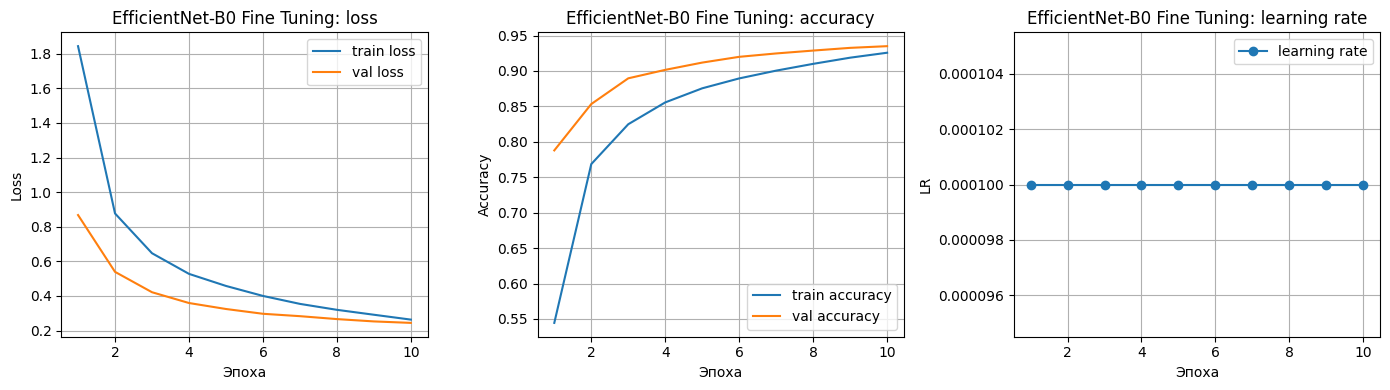

In [15]:
def create_efficientnet_b0_fine_tuning(num_classes):
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    for param in model.parameters():
        param.requires_grad = False

    # Дообучаем последние блоки EfficientNet и новый classifier.
    for param in model.features[-2:].parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


set_random_seed(SEED)
efficientnet_ft_model = create_efficientnet_b0_fine_tuning(num_classes)
efficientnet_ft_total_params = count_parameters(efficientnet_ft_model)
efficientnet_ft_trainable_params = count_trainable_parameters(efficientnet_ft_model)
show_trainable_parameters(efficientnet_ft_model)

backbone_params = []
classifier_params = []

for name, param in efficientnet_ft_model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith('classifier'):
        classifier_params.append(param)
    else:
        backbone_params.append(param)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': 1e-4},
        {'params': classifier_params, 'lr': 1e-3},
    ],
    weight_decay=1e-4,
)

efficientnet_ft_model, efficientnet_ft_history = train(
    efficientnet_ft_model,
    criterion,
    optimizer,
    train_batch_gen,
    val_batch_gen,
    num_epochs=NUM_EPOCHS,
)

print_history_summary('EfficientNet-B0 Fine Tuning', efficientnet_ft_history)
plot_history(efficientnet_ft_history, 'EfficientNet-B0 Fine Tuning')

del efficientnet_ft_model, optimizer, backbone_params, classifier_params
clear_gpu_memory()

## 15. Сравнение моделей

Сравним ResNet18 с нуля и две стратегии использования pretrained EfficientNet-B0. Таблица формируется программно из history.

,Model,Training method,Best validation accuracy,Final validation accuracy,Best validation loss,Training time,Number of parameters,Trainable parameters
0,ResNet18,Training from scratch,0.871746,0.849534,0.527458,1158.186143,11198058,11198058
1,EfficientNet-B0,Feature Extractor,0.740626,0.740626,1.000191,1057.386931,4061350,53802
2,EfficientNet-B0,Fine Tuning,0.935037,0.935037,0.244564,1064.793896,4061350,1183194


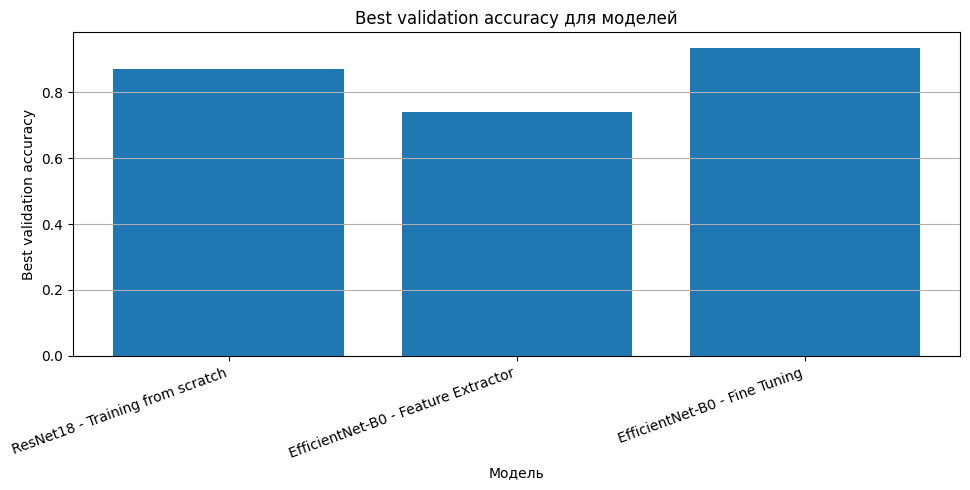

In [16]:
def make_model_comparison_row(model_name, training_method, history, total_params, trainable_params):
    return {
        'Model': model_name,
        'Training method': training_method,
        'Best validation accuracy': best_val_accuracy(history),
        'Final validation accuracy': final_val_accuracy(history),
        'Best validation loss': best_val_loss(history),
        'Training time': history['training_time_sec'],
        'Number of parameters': total_params,
        'Trainable parameters': trainable_params,
    }


model_comparison_df = pd.DataFrame([
    make_model_comparison_row(
        'ResNet18',
        'Training from scratch',
        baseline_history,
        baseline_total_params,
        baseline_trainable_params,
    ),
    make_model_comparison_row(
        'EfficientNet-B0',
        'Feature Extractor',
        efficientnet_fe_history,
        efficientnet_fe_total_params,
        efficientnet_fe_trainable_params,
    ),
    make_model_comparison_row(
        'EfficientNet-B0',
        'Fine Tuning',
        efficientnet_ft_history,
        efficientnet_ft_total_params,
        efficientnet_ft_trainable_params,
    ),
])

display(model_comparison_df)

plt.figure(figsize=(10, 5))
plt.bar(
    model_comparison_df['Model'] + ' - ' + model_comparison_df['Training method'],
    model_comparison_df['Best validation accuracy'],
)
plt.title('Best validation accuracy для моделей')
plt.xlabel('Модель')
plt.ylabel('Best validation accuracy')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Выводы

Следующая ячейка формирует итоговый Markdown-вывод на основе фактически полученных значений. Если notebook еще не выполнен, чисел здесь не будет; после `Runtime -> Run all` вывод заполнится автоматически.

In [17]:
best_scheduler_row = scheduler_comparison_df.loc[scheduler_comparison_df['Best val accuracy'].idxmax()]
best_model_row = model_comparison_df.loc[model_comparison_df['Best validation accuracy'].idxmax()]
fastest_model_row = model_comparison_df.loc[model_comparison_df['Training time'].idxmin()]
cheapest_model_row = model_comparison_df.loc[model_comparison_df['Trainable parameters'].idxmin()]

step_lr_final = final_val_accuracy(step_lr_history)
plateau_final = final_val_accuracy(plateau_history)

conclusion_text = f'''
# Выводы

1. **StepLR** изменял learning rate по заранее заданному расписанию. В этом запуске ResNet18 со StepLR получил best validation accuracy **{best_val_accuracy(step_lr_history):.2%}**, final validation accuracy **{step_lr_final:.2%}** и best validation loss **{best_val_loss(step_lr_history):.4f}**.

2. **ReduceLROnPlateau** реагировал на validation loss и уменьшал learning rate только тогда, когда качество переставало улучшаться. В этом запуске он получил best validation accuracy **{best_val_accuracy(plateau_history):.2%}**, final validation accuracy **{plateau_final:.2%}** и best validation loss **{best_val_loss(plateau_history):.4f}**.

3. Лучший scheduler по validation accuracy: **{best_scheduler_row['Scheduler']}** с результатом **{best_scheduler_row['Best val accuracy']:.2%}**.

4. Scheduler способен улучшать обучение, потому что большой learning rate полезен в начале для быстрого движения к хорошей области, а меньший learning rate ближе к концу помогает аккуратнее донастраивать веса и не перескакивать через минимум loss.

5. При чрезмерных train-аугментациях best validation accuracy снизилась на **{accuracy_drop * 100:.2f} процентных пункта**: с **{normal_best_val_accuracy:.2%}** до **{bad_aug_best_val_accuracy:.2%}**.

6. Слишком сильные аугментации вредят, потому что изображения перестают соответствовать реальному распределению validation данных. Геометрия, цвет и важные визуальные признаки персонажей искажаются, поэтому модель учится на объектах, которые хуже похожи на реальные данные.

7. **Обучение с нуля** обновляет все веса модели и требует больше данных. **Feature Extractor** замораживает pretrained backbone и обучает только новый классификатор. **Fine Tuning** дообучает новый classifier и часть pretrained слоев, поэтому может лучше адаптироваться к Simpsons, но требует больше вычислений и аккуратного learning rate.

8. В сравнении ResNet18 и EfficientNet-B0 лучший результат по validation accuracy получил вариант **{best_model_row['Model']} - {best_model_row['Training method']}**: **{best_model_row['Best validation accuracy']:.2%}**.

9. По скорости обучения быстрее всего оказался вариант **{fastest_model_row['Model']} - {fastest_model_row['Training method']}**: **{fastest_model_row['Training time']:.1f} секунд**. По числу обучаемых параметров самый экономный вариант: **{cheapest_model_row['Model']} - {cheapest_model_row['Training method']}** с **{int(cheapest_model_row['Trainable parameters']):,}** обучаемыми параметрами.

10. Для дальнейшей работы разумно выбрать вариант **{best_model_row['Model']} - {best_model_row['Training method']}**, если главный критерий - validation accuracy. Если важнее скорость и вычислительные затраты, нужно дополнительно учитывать время обучения и число обучаемых параметров из итоговой таблицы.
'''

display(Markdown(conclusion_text))


# Выводы

1. **StepLR** изменял learning rate по заранее заданному расписанию. В этом запуске ResNet18 со StepLR получил best validation accuracy **90.37%**, final validation accuracy **90.37%** и best validation loss **0.3675**.

2. **ReduceLROnPlateau** реагировал на validation loss и уменьшал learning rate только тогда, когда качество переставало улучшаться. В этом запуске он получил best validation accuracy **87.15%**, final validation accuracy **71.17%** и best validation loss **0.4940**.

3. Лучший scheduler по validation accuracy: **StepLR** с результатом **90.37%**.

4. Scheduler способен улучшать обучение, потому что большой learning rate полезен в начале для быстрого движения к хорошей области, а меньший learning rate ближе к концу помогает аккуратнее донастраивать веса и не перескакивать через минимум loss.

5. При чрезмерных train-аугментациях best validation accuracy снизилась на **75.19 процентных пункта**: с **87.17%** до **11.99%**.

6. Слишком сильные аугментации вредят, потому что изображения перестают соответствовать реальному распределению validation данных. Геометрия, цвет и важные визуальные признаки персонажей искажаются, поэтому модель учится на объектах, которые хуже похожи на реальные данные.

7. **Обучение с нуля** обновляет все веса модели и требует больше данных. **Feature Extractor** замораживает pretrained backbone и обучает только новый классификатор. **Fine Tuning** дообучает новый classifier и часть pretrained слоев, поэтому может лучше адаптироваться к Simpsons, но требует больше вычислений и аккуратного learning rate.

8. В сравнении ResNet18 и EfficientNet-B0 лучший результат по validation accuracy получил вариант **EfficientNet-B0 - Fine Tuning**: **93.50%**.

9. По скорости обучения быстрее всего оказался вариант **EfficientNet-B0 - Feature Extractor**: **1057.4 секунд**. По числу обучаемых параметров самый экономный вариант: **EfficientNet-B0 - Feature Extractor** с **53,802** обучаемыми параметрами.

10. Для дальнейшей работы разумно выбрать вариант **EfficientNet-B0 - Fine Tuning**, если главный критерий - validation accuracy. Если важнее скорость и вычислительные затраты, нужно дополнительно учитывать время обучения и число обучаемых параметров из итоговой таблицы.
